In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
df = pd.read_csv("generated_crystals_cifs/voltage_analysis.csv")
df_old100 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_old2048 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_train = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20/train.csv")

In [3]:
df

,pretty_formula,filename,num_atoms,host_energy,Li_energy,Na_energy,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,host_structure,Li_structure,Na_structure
0,LiLaCrBiO6,gen_0,10.0,-61.956871,-66.956350,-65.809015,-6.884097,-6.695635,-6.580901,0.056280,-0.167156,# generated using pymatgen\ndata_LaCrBiO6\n_sy...,# generated using pymatgen\ndata_LiLaCrBiO6\n_...,# generated using pymatgen\ndata_NaLaCrBiO6\n_...
1,LiCr(NF)4,gen_1,10.0,-58.176579,-64.994732,-64.201340,-6.464064,-6.499473,-6.420134,1.874954,2.005462,# generated using pymatgen\ndata_Cr(NF)4\n_sym...,# generated using pymatgen\ndata_LiCr(NF)4\n_s...,# generated using pymatgen\ndata_NaCr(NF)4\n_s...
2,NaSbP(OF)4,gen_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LiMnF4,gen_100,12.0,-49.423873,-64.617464,-62.960007,-4.942387,-5.384789,-5.246667,2.653596,2.748767,# generated using pymatgen\ndata_MnF4\n_symmet...,# generated using pymatgen\ndata_LiMnF4\n_symm...,# generated using pymatgen\ndata_NaMnF4\n_symm...
4,PrP4WN9O5,gen_1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,LiCr(NiO2)2,gen_862,8.0,-40.740721,-46.381507,-44.568263,-5.820103,-5.797688,-5.571033,0.697586,-0.191758,# generated using pymatgen\ndata_Cr(NiO2)2\n_s...,# generated using pymatgen\ndata_LiCr(NiO2)2\n...,# generated using pymatgen\ndata_NaCr(NiO2)2\n...
1897,LiPdF3,gen_863,5.0,-12.036673,-19.750386,-20.672714,-3.009168,-3.950077,-4.134543,2.770513,4.616741,# generated using pymatgen\ndata_PdF3\n_symmet...,# generated using pymatgen\ndata_LiPdF3\n_symm...,# generated using pymatgen\ndata_NaPdF3\n_symm...
1898,Cr2O3,gen_864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1899,LiCrF4,gen_865,12.0,-51.638040,-67.137147,-65.096431,-5.163804,-5.594762,-5.424703,2.806354,2.709896,# generated using pymatgen\ndata_CrF4\n_symmet...,# generated using pymatgen\ndata_LiCrF4\n_symm...,# generated using pymatgen\ndata_NaCrF4\n_symm...


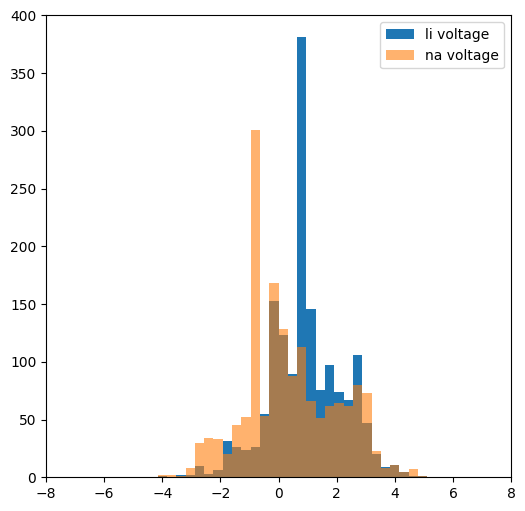

In [4]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage'],label="li voltage",bins=50,range=(-8,8))
plt.hist(df['Na_voltage'],label="na voltage",bins=50,range=(-8,8),alpha=0.6)
plt.xlim(-8,8)
plt.legend()
plt.show()

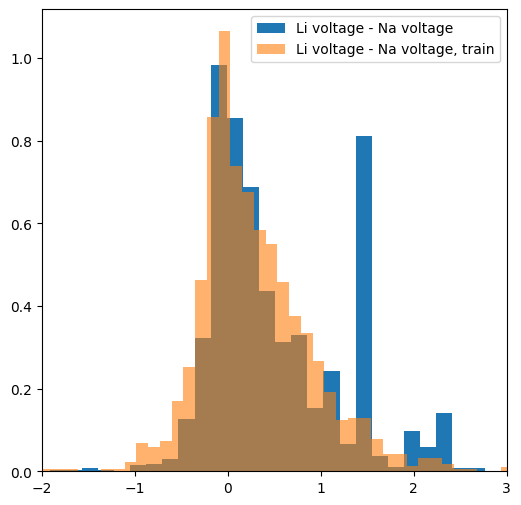

In [5]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage']-df['Na_voltage'],label="Li voltage - Na voltage",bins=50,density=True)
plt.hist(df_train['Li_voltage']-df_train['Na_voltage'],label="Li voltage - Na voltage, train",bins=50,alpha=0.6,density=True)
plt.xlim(-2,3)
plt.legend()
plt.show()

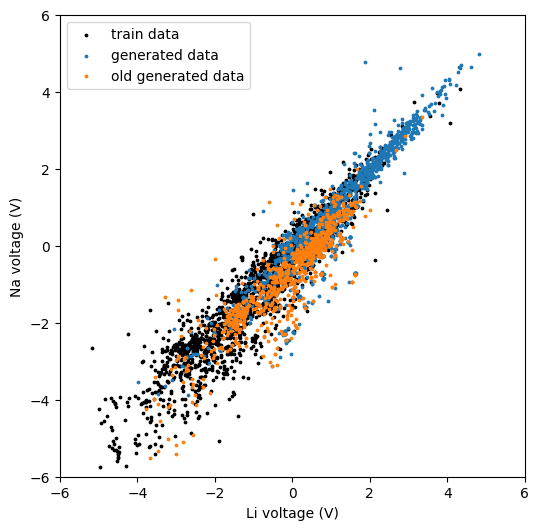

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="train data",c='k')
plt.scatter(df['Li_voltage'],df['Na_voltage'],s=3,label="generated data")
plt.scatter(df_old2048['Li_voltage'],df_old2048['Na_voltage'],s=3,label="old generated data")
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()


In [26]:
df_to_add = df[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']

/tmp/ipykernel_1996265/4151272627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']


In [27]:
df_old_to_add = df_old[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_old_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage'] 

/tmp/ipykernel_1996265/1798932268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage']


In [33]:
df_merged = pd.concat([df_train,df_to_add,df_old_to_add],ignore_index=True)

In [35]:
# remove nan rows except if Nan is only in 'material_id' column
df_merged_cleaned = df_merged.dropna(subset=['Li_voltage', 'Na_voltage', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom'])

In [37]:
df_merged_cleaned.to_csv("train_extended_cleaned.csv",index=False)

In [38]:
df_merged_cleaned

,pretty_formula,material_id,num_atoms,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,cif
0,Rb2LiBi2O5,mp-975106,10.0,-5.001463,-4.840352,-4.775824,-1.552852,-1.274225,# generated using pymatgen\ndata_Rb2LiBi2O5\n_...
1,LiVCl2O,mp-1216404,5.0,-5.365562,-5.168905,-4.801249,-0.560927,-1.475303,# generated using pymatgen\ndata_LiVCl2O\n_sym...
2,LiScTl(MoO4)2,mp-19450,13.0,-7.246476,-6.905751,-6.844393,-2.126157,-1.999905,# generated using pymatgen\ndata_LiScTl(MoO4)2...
3,Li4Cr3FeO8,mp-756058,16.0,-6.821576,-6.671563,-6.509723,0.678274,0.307453,# generated using pymatgen\ndata_Li4Cr3FeO8\n_...
4,Ba4Li(Co2O5)2,mp-1076439,19.0,-6.059365,-5.934136,-5.872205,-1.263181,-1.515970,# generated using pymatgen\ndata_Ba4Li(Co2O5)2...
...,...,...,...,...,...,...,...,...,...
3862,LiCr2NiO6,NaN,10.0,-6.418833,-6.344823,-6.205362,0.735528,0.470709,# generated using pymatgen\ndata_LiCr2NiO6\n_s...
3864,LiAlCr5O8,NaN,15.0,-7.741191,-7.435713,-7.356704,-1.784173,0.261232,# generated using pymatgen\ndata_LiAlCr5O8\n_s...
3866,LiCr2(NiO2)2,NaN,9.0,-6.042746,-5.595628,-5.691299,-2.924517,-1.784939,# generated using pymatgen\ndata_LiCr2(NiO2)2\...
3868,LiCr(SbO4)2,NaN,12.0,-6.106551,-6.136741,-6.015783,1.525626,0.527599,# generated using pymatgen\ndata_LiCr(SbO4)2\n...
